In [1]:
import tifffile as tiff
from matplotlib import pyplot as plt
from aicsimageio import AICSImage
from tifffile import imsave
from PIL import Image
import numpy as np
import os
import pandas as pd
import seaborn as sns


Converting xenium DAPI images to suitable format for valis image registration

In [ ]:
### convering all xenium dapi images for registration
### we are using the morphology focus image for registration fr all our samples
### these have been imported into a common folder 

root = '/home/shamini/data2/projects/chiba_pathomics/'
data_dir = root + 'data/'

xenium_dir = data_dir + 'Xenium Output Glioma TMA/'

out_root = root + 'out_feb2025/'
os.makedirs(out_root, exist_ok=True)



In [10]:
dapi = xenium_dir+'morphology_focus.ome.tif'
image_out = out_root+'script01ab_converted_images_for_valis_reg/'
os.makedirs(image_out, exist_ok=True)

dapi_he_reg = image_out + 'reg01_dapi_he/'
msi_he_reg = image_out + 'reg02_msi_he/'

os.makedirs(dapi_he_reg, exist_ok=True)
os.makedirs(msi_he_reg, exist_ok=True)

print(dapi)
dapi = AICSImage(dapi)

# Check available dimensions and channels
print("Dimensions:", dapi.dims)

dapi_data = dapi.get_image_data("YX", T=0, C=0, Z=0)
#dapi_data_uint8 = (dapi_data / np.max(dapi_data) * 255).astype(np.uint8)

if dapi_data.dtype != np.uint8:
    dapi_data_uint8 = (dapi_data / np.max(dapi_data) * 255).astype(np.uint8)
else:
    dapi_data_uint8 = dapi_data

        
# Create a PIL Image object from the numpy array
pil_image = Image.fromarray(dapi_data_uint8)

print("Saving image...")
pil_image.save(dapi_he_reg+'morphology_focus_valis.tiff')



/home/shamini/data/projects/chiba_pathomics/data/Xenium Output Glioma TMA/morphology_focus.ome.tif
Dimensions: <Dimensions [T: 1, C: 1, Z: 1, Y: 91807, X: 42880]>
Saving image...


Import HE image, process and save for valis registration

In [5]:
###
# he = tiff.imread(data_dir+'Chiba_folder_from_Trevor/he_0006234_0.4x.tif') ### low resolution
he = tiff.imread(data_dir+'Chiba_folder_from_Trevor/he_0006234_Scan1_resolution_#1.tif') ### high resolution


Text(0.5, 1.0, 'HE')

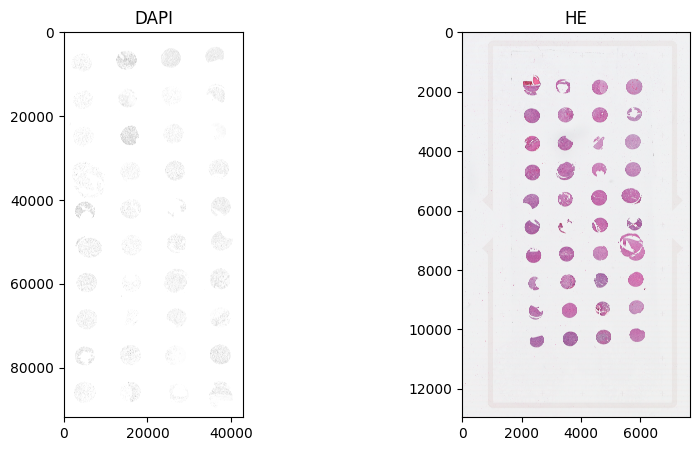

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(dapi_data_uint8, cmap='gray_r')
axes[0].set_title('DAPI')

axes[1].imshow(he)
axes[1].set_title('HE')


In [ ]:
he.shape

In [7]:
new_he = he[500:12000, 1000:7000,:] ### only for high resolution HE image

Text(0.5, 1.0, 'HE')

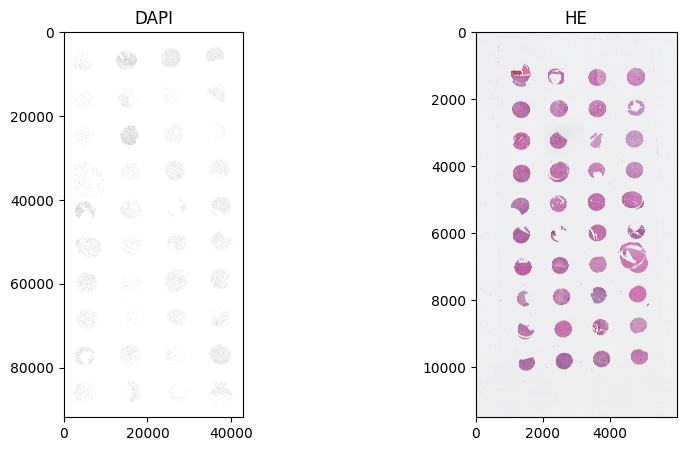

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(dapi_data_uint8, cmap='gray_r')
axes[0].set_title('DAPI')

axes[1].imshow(new_he)
axes[1].set_title('HE')

In [ ]:
#he = he[:, :, :3] ## for low res

#plt.imshow(he[800:1200, 50:900, :]) ### for low res
#new_he = he[800:1200, 50:900, :] ### for low res
### transpose the image 
#new_he = np.transpose(new_he, (1, 0, 2)) ### for low res
#plt.imshow(new_he) ### for low res

In [ ]:
#new_he.shape

In [11]:
tiff.imsave(dapi_he_reg+'/he_rotated_3dim.tif', new_he)

/tmp/ipykernel_543667/1034941863.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tiff.imsave(dapi_he_reg+'/he_rotated_3dim.tif', new_he)


Import MSI images 

In [12]:
#metab = pd.read_excel('/home/shamini/data/projects/chiba_pathomics/data/Multi omics integration/Metabolism Coordinates.xls')
#img = tiff.imread(data_dir+'Xenium Output Glioma TMA/morphology_focus.ome.tif')

maldi_glycans = tiff.imread(data_dir+'/Chiba_folder_from_Trevor/MALDI/240413 Ene glioma manual glycans.ome.ome.tif')
mets = tiff.imread(data_dir+'/Chiba_folder_from_Trevor/MALDI/240413 Ene glioma manual mets.ome.ome.tif')
peptides = tiff.imread(data_dir+'/Chiba_folder_from_Trevor/MALDI/240413 Ene glioma manual peptides.ome.ome.tif')
maldi_glycans_meta = tiff.TiffFile('/home/shamini/data/projects/chiba_pathomics/data/Chiba_folder_from_Trevor/MALDI/240413 Ene glioma manual glycans.ome.ome.tif')
maldi_glycans_meta.pages[0].tags['XResolution'].value

(500, 1)

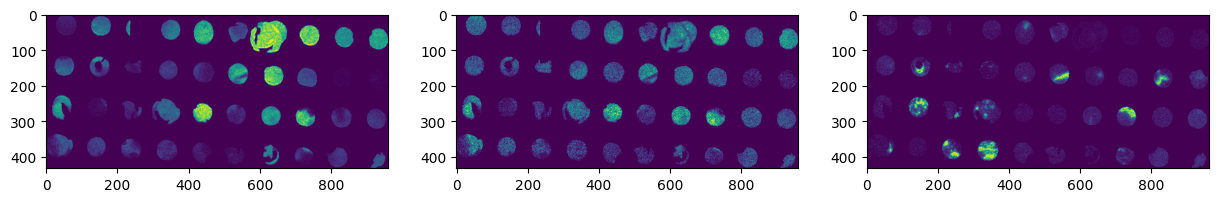

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(peptides[21])
axes[1].imshow(peptides[45])
axes[2].imshow(peptides[59])

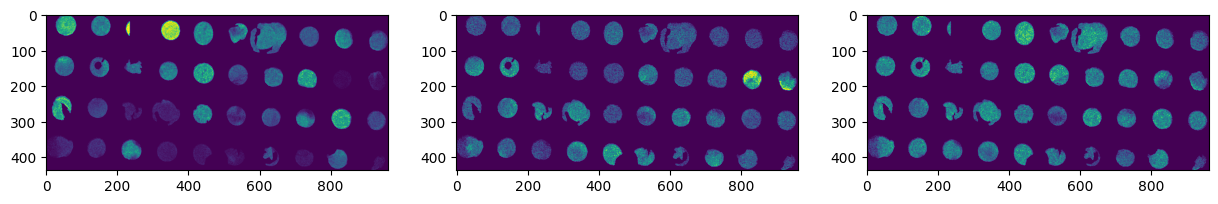

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(maldi_glycans[0])
axes[1].imshow(maldi_glycans[12])
axes[2].imshow(maldi_glycans[18])

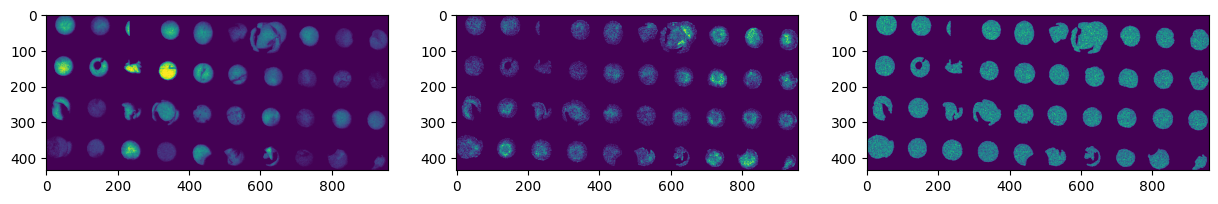

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mets[0])
axes[1].imshow(mets[65])
axes[2].imshow(mets[160])

In [16]:
#fig, axes = plt.subplots(1, 1, figsize=(10, 5))

#axes.imshow(peptides[16, :, :])
#metab2 = metab[['x', 'y']]/19.75
#metab2['y'] = peptides.shape[1] - metab2['y']
#sns.scatterplot(x='x', y='y', data=metab2, s=1, color='red', axes=axes)


In [17]:
maldi_glycans.shape, mets.shape, peptides.shape, 

((287, 437, 962), (670, 435, 958), (818, 432, 961))

In [18]:
### save the above files but first combine each set into one image , mimicking a RGB image
peptides_rep = np.zeros((1, peptides.shape[1], peptides.shape[2]), dtype=peptides.dtype)
peptides_rep = peptides[21]
#peptides_combined[1, :, :] = peptides[45]
#peptides_combined[2, :, :] = peptides[59]

In [19]:
maldi_gycans_rep = np.zeros((1, maldi_glycans.shape[1], maldi_glycans.shape[2]), dtype=maldi_glycans.dtype)
maldi_gycans_rep = maldi_glycans[0]
#maldi_gycans_combined[1, :, :] = maldi_glycans[12]
#maldi_gycans_combined[2, :, :] = maldi_glycans[18]

In [20]:
mets_rep = np.zeros((1, mets.shape[1], mets.shape[2]), dtype=mets.dtype)
mets_rep = mets[0]
#mets_combined[1, :, :] = mets[65]
#mets_combined[2, :, :] = mets[160]

In [21]:
peptides_rep.shape, maldi_gycans_rep.shape, mets_rep.shape

((432, 961), (437, 962), (435, 958))

In [22]:
### give 50 pixel padding to all sides
peptides_rep = np.pad(peptides_rep, ((50, 50), (50, 50)), mode='constant')
maldi_gycans_rep = np.pad(maldi_gycans_rep, ((50, 50), (50, 50)), mode='constant')
mets_rep = np.pad(mets_rep, ((50, 50), (50, 50)), mode='constant')

#peptides_combined = np.pad(peptides_combined, ((0, 0), (50, 50), (50, 50)), mode='constant')
#maldi_gycans_combined = np.pad(maldi_gycans_combined, ((0, 0), (50, 50), (50, 50)), mode='constant')
#mets_combined = np.pad(mets_combined, ((0, 0), (50, 50), (50, 50)), mode='constant')

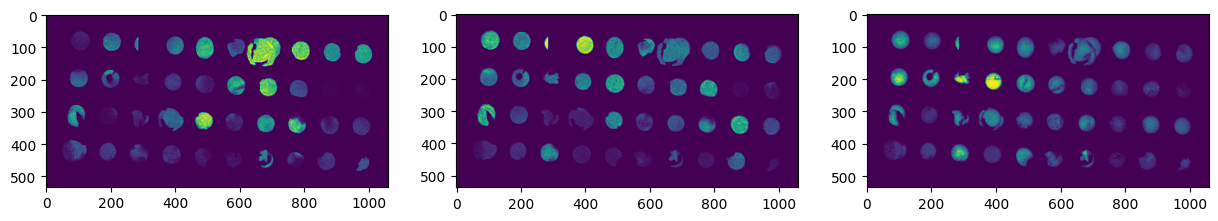

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(peptides_rep)
axes[1].imshow(maldi_gycans_rep)
axes[2].imshow(mets_rep)

In [24]:
peptides_rep.shape, he.shape

((532, 1061), (12960, 7680, 3))

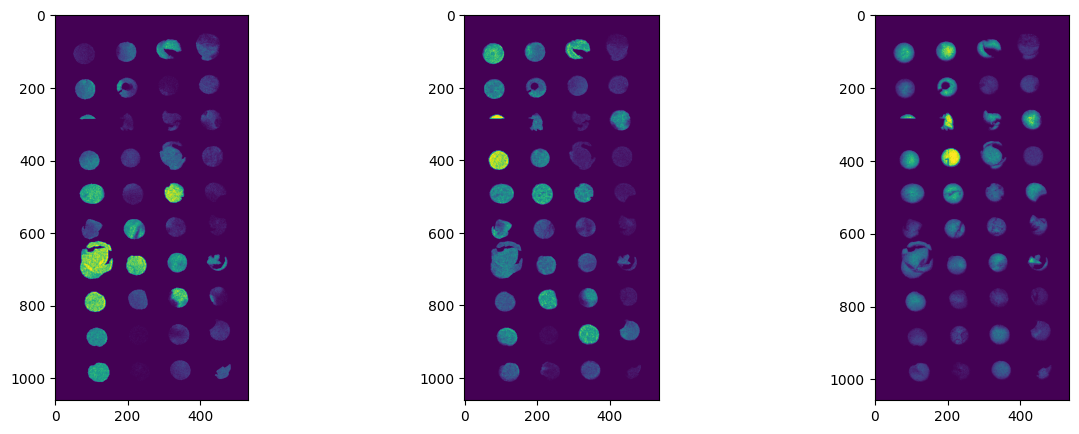

In [25]:
peptides_rep = np.transpose(peptides_rep, (1, 0))
maldi_gycans_rep = np.transpose(maldi_gycans_rep, (1, 0))
mets_rep = np.transpose(mets_rep, (1, 0))

#peptides_combined = np.transpose(peptides_combined, (2, 1, 0))
#mets_combined = np.transpose(mets_combined, (2, 1, 0))
#maldi_gycans_combined = np.transpose(maldi_gycans_combined, (2, 1, 0))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(peptides_rep)
axes[1].imshow(maldi_gycans_rep)
axes[2].imshow(mets_rep)



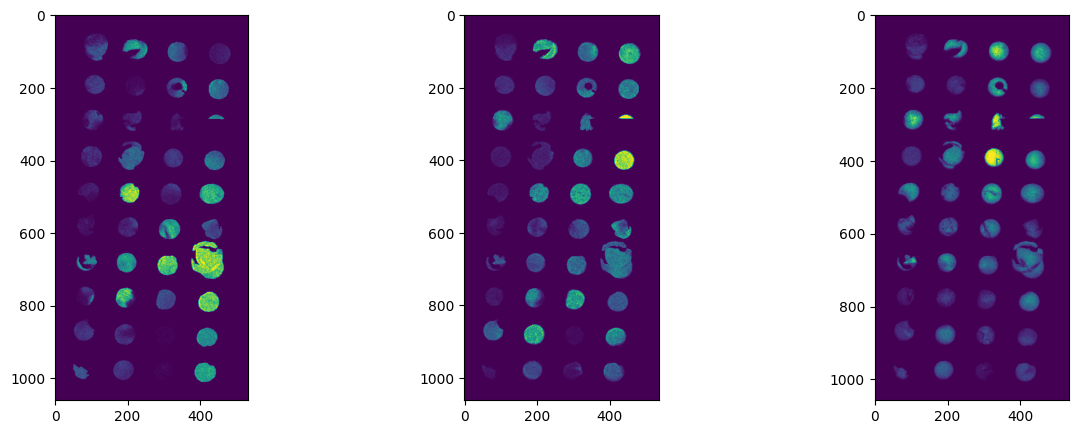

In [26]:
### reflect the image
peptides_rep = np.fliplr(peptides_rep)
maldi_gycans_rep = np.fliplr(maldi_gycans_rep)
mets_rep = np.fliplr(mets_rep)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(peptides_rep)
axes[1].imshow(maldi_gycans_rep)
axes[2].imshow(mets_rep)

In [ ]:
### create new images with the maximum intensity from each channel copied over



In [33]:
### save each image

tiff.imwrite(msi_he_reg+'peptides_rep.tif', peptides_rep)
tiff.imwrite(msi_he_reg+'maldi_gycans_rep.tif', maldi_gycans_rep)
tiff.imwrite(msi_he_reg+'mets_rep.tif', mets_rep)

tiff.imwrite(dapi_he_reg+'peptides_reg.tif', peptides_rep)
tiff.imwrite(dapi_he_reg+'maldi_gycans_reg.tif', maldi_glycans)
tiff.imwrite(dapi_he_reg+'mets_reg.tif', mets_rep)

### note - having 3 channels leads to valis failture. Tried with 1 good msi channel and it works fine actually
#tiff.imwrite(msi_he_reg+'peptides_combined.tif', peptides_combined[:,:,0])
#tiff.imwrite(msi_he_reg+'maldi_gycans_combined.tif', maldi_gycans_combined[:,:,0])
#tiff.imwrite(msi_he_reg+'mets_combined.tif', mets_combined[:,:,0])
